# 01 — Model Loading & Exploration:
Load the model, inspect its architecture, understand the MoE routing structure. How many experts? How does the router decide which experts activate? Print the model's module tree, count parameters per component.

In [ ]:
from transformers import AutoModelForCausalLM, AutoTokenizer

# Load our model and tokenizer
model = AutoModelForCausalLM.from_pretrained("deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct")
tokenizer = AutoTokenizer.from_pretrained("deepseek-ai/DeepSeek-Coder-V2-Lite-Instruct")

`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


Loading weights:   0%|          | 0/351 [00:00<?, ?it/s]

`rope_parameters`'s factor field must be a float >= 1, got 40
`rope_parameters`'s beta_fast field must be a float, got 32
`rope_parameters`'s beta_slow field must be a float, got 1


In [ ]:
# Let's take a look
print(model)

DeepseekV2ForCausalLM(
  (model): DeepseekV2Model(
    (embed_tokens): Embedding(102400, 2048)
    (layers): ModuleList(
      (0): DeepseekV2DecoderLayer(
        (self_attn): DeepseekV2Attention(
          (q_proj): Linear(in_features=2048, out_features=3072, bias=False)
          (kv_a_proj_with_mqa): Linear(in_features=2048, out_features=576, bias=False)
          (kv_a_layernorm): DeepseekV2RMSNorm((512,), eps=1e-06)
          (kv_b_proj): Linear(in_features=512, out_features=4096, bias=False)
          (o_proj): Linear(in_features=2048, out_features=2048, bias=False)
        )
        (mlp): DeepseekV2MLP(
          (gate_proj): Linear(in_features=2048, out_features=10944, bias=False)
          (up_proj): Linear(in_features=2048, out_features=10944, bias=False)
          (down_proj): Linear(in_features=10944, out_features=2048, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): DeepseekV2RMSNorm((2048,), eps=1e-06)
        (post_attention_layern

In [ ]:
# Let's look at the MOE layer
print(model.model.layers[1].mlp.experts)

DeepseekV2Experts(
  (act_fn): SiLUActivation()
)


In [ ]:
# Dig in deeper
for name, param in model.model.layers[1].mlp.experts.named_parameters():
    print(name, param.shape)

gate_up_proj torch.Size([64, 2816, 2048])
down_proj torch.Size([64, 2048, 1408])


In [ ]:
# Let's figure out what our layers look like
count = 0
for i, layer in enumerate(model.model.layers):
    has_moe = hasattr(layer.mlp, 'experts')
    print(f"Layer {i}: {'MoE' if has_moe else 'Dense'}")
    count += 1
print("Total Layers: " + str(count))

Layer 0: Dense
Layer 1: MoE
Layer 2: MoE
Layer 3: MoE
Layer 4: MoE
Layer 5: MoE
Layer 6: MoE
Layer 7: MoE
Layer 8: MoE
Layer 9: MoE
Layer 10: MoE
Layer 11: MoE
Layer 12: MoE
Layer 13: MoE
Layer 14: MoE
Layer 15: MoE
Layer 16: MoE
Layer 17: MoE
Layer 18: MoE
Layer 19: MoE
Layer 20: MoE
Layer 21: MoE
Layer 22: MoE
Layer 23: MoE
Layer 24: MoE
Layer 25: MoE
Layer 26: MoE
Total Layers: 27


In [ ]:
total = 0
for name, param in model.named_parameters():
    total += param.numel()
print(f"Total parameters: {total:,}")

Total parameters: 15,706,484,224


In [19]:
print(model.config)

DeepseekV2Config {
  "architectures": [
    "DeepseekV2ForCausalLM"
  ],
  "attention_bias": false,
  "attention_dropout": 0.0,
  "auto_map": {
    "AutoConfig": "configuration_deepseek.DeepseekV2Config",
    "AutoModel": "modeling_deepseek.DeepseekV2Model",
    "AutoModelForCausalLM": "modeling_deepseek.DeepseekV2ForCausalLM"
  },
  "aux_loss_alpha": 0.001,
  "bos_token_id": 100000,
  "dtype": "bfloat16",
  "eos_token_id": 100001,
  "first_k_dense_replace": 1,
  "head_dim": 64,
  "hidden_act": "silu",
  "hidden_size": 2048,
  "initializer_range": 0.02,
  "intermediate_size": 10944,
  "kv_lora_rank": 512,
  "max_position_embeddings": 163840,
  "mlp_bias": false,
  "model_type": "deepseek_v2",
  "moe_intermediate_size": 1408,
  "moe_layer_freq": 1,
  "n_group": 1,
  "n_routed_experts": 64,
  "n_shared_experts": 2,
  "norm_topk_prob": false,
  "num_attention_heads": 16,
  "num_experts_per_tok": 6,
  "num_hidden_layers": 27,
  "num_key_value_heads": 16,
  "pad_token_id": null,
  "pretrain

In [ ]:
from collections import defaultdict

# Let's look at the parameter distribution
counts = defaultdict(int)
for name, param in model.named_parameters():
    if 'embed' in name or 'lm_head' in name:
        counts['embeddings/head'] += param.numel()
    elif 'self_attn' in name:
        counts['attention'] += param.numel()
    elif 'shared_experts' in name:
        counts['shared_experts'] += param.numel()
    elif 'experts' in name:
        counts['routed_experts'] += param.numel()
    elif 'gate' in name:
        counts['gate/router'] += param.numel()
    elif 'norm' in name:
        counts['norms'] += param.numel()
    else:
        counts['other'] += param.numel()

total = sum(counts.values())
for component, count in sorted(counts.items(), key=lambda x: -x[1]):
    print(f"{component:20s} {count:>14,}  ({count/total*100:5.1f}%)")
print(f"{'TOTAL':20s} {total:>14,}")

routed_experts       14,394,851,328  ( 91.6%)
shared_experts          449,839,104  (  2.9%)
embeddings/head         419,430,400  (  2.7%)
attention               371,602,944  (  2.4%)
other                    44,826,624  (  0.3%)
gate/router              25,821,184  (  0.2%)
norms                       112,640  (  0.0%)
TOTAL                15,706,484,224


### Let's visualize the parameters on a log scale

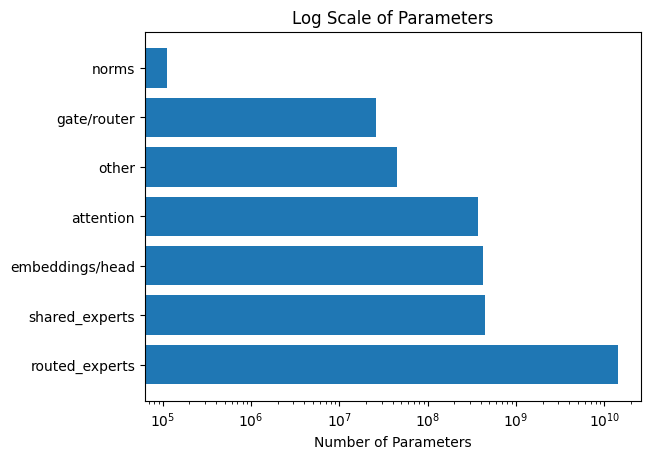

In [ ]:
import matplotlib.pyplot as plt

components = list(sorted(counts.items(), key=lambda x: -x[1]))
names = [c[0] for c in components]
values = [c[1] for c in components]

labels = list(counts.keys())
nums = list(counts.values())

sorted_pairs = sorted(zip(labels, nums), key=lambda x: x[1], reverse=True)
sorted_labels = [p[0] for p in sorted_pairs]
sorted_nums = [p[1] for p in sorted_pairs]

plt.barh(sorted_labels, sorted_nums)
plt.title('Log Scale of Parameters')
plt.xlabel('Number of Parameters')
plt.xscale('log')
plt.show()

In [104]:
prompt = "def fibonacci(n):"
inputs = tokenizer(prompt, return_tensors="pt")
outputs = model.generate(**inputs, max_new_tokens=100)

text = tokenizer.decode(outputs[0])
print(text.replace('Ġ', ' ').replace('Ċ', '\n'))

Setting `pad_token_id` to `eos_token_id`:100001 for open-end generation.


deffibonacci(n):
    if n <= 1:
        return n
    else:
        return deffibonacci(n-1) + deffibonacci(n-2)

print(deffibonacci(10))

# Memoization
def fibonacci(n, memo={}):
    if n in memo:
        return memo[n]
    if n <= 1:
        return n
    else:
        memo[


#### Time to test the code generation

In [ ]:
# Did some minor cleanup - changed 'deffibonacci' to 'fibonacci' in the 'else' part of the loop.
def fibonacci(n):
    if n <= 1:
        return n
    else:
        return fibonacci(n-1) + fibonacci(n-2)
    
print(fibonacci(9))

34


Success!

---
**Key findings**:
- 27 layers: 1 dense (layer 0) + 26 MoE
- 64 routed experts per MoE layer, top-6 activated per token
- 2 shared experts (always active) per MoE layer
- 15.7B total params, 91.6% in routed experts
- Model generates correct code at FP16 (confirmed with fibonacci)